# 14 — Organisation-Wide Skill Gap

**Day 3, Step 14.** The same logic rolled up across everyone.

The Build Notes set severity by absolute headcount (100+ HIGH, 50+ MEDIUM).
Those are converted to a **share of the workforce** so they keep meaning as
headcount changes — the same rule, made scalable.

In [1]:
import sys, warnings
sys.path.insert(0, "../src"); sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# The lab imports from the factory. Nothing below reimplements pipeline logic.
from hrai.utils.config import get, raw_path, seed
from hrai.utils.io import load_raw, load_processed
from hrai.utils.logger import setup_logging
setup_logging(fmt="human")
print(f"seed={seed()}  |  datasets: {sorted(get('datasets'))}")

seed=42  |  datasets: ['employee_attrition', 'essential_skills', 'hr_performance_engagement', 'occupation_data', 'software_skills']


In [2]:
from hrai.skills.employee_skills import build_employee_skills
from hrai.skills.gap import compute_skill_gaps, organisation_skill_gaps

org = organisation_skill_gaps(compute_skill_gaps(build_employee_skills()))
print("severity bands:", org.severity_band.value_counts().to_dict())
org.head(15)

2026-08-28 01:55:14 | INFO  | crosswalk resolved


2026-08-28 01:55:14 | INFO  | role requirements built


2026-08-28 01:55:14 | INFO  | employee skills derived


2026-08-28 01:55:14 | INFO  | skill gaps computed


2026-08-28 01:55:14 | INFO  | organisation-wide skill gaps rolled up


severity bands: {'LOW': 128, 'MEDIUM': 40, 'HIGH': 17}


,skill_name,tier,employees_missing,mean_severity,total_severity,pct_of_workforce,severity_band
0,SAP,technical,2179,0.7639,1664.5,0.4875,HIGH
1,The MathWorks MATLAB,technical,1936,0.75,1452.0,0.4331,HIGH
2,Microsoft SharePoint,technical,1899,0.7541,1432.0,0.4248,HIGH
3,Microsoft Access,technical,1842,0.7535,1388.0,0.4121,HIGH
4,Microsoft Word,technical,1668,0.8041,1341.25,0.3732,HIGH
5,Microsoft Visio,technical,1649,0.75,1236.75,0.3689,HIGH
6,R,technical,1528,0.7667,1171.5,0.3418,HIGH
7,SQL,technical,1443,0.8001,1154.5,0.3228,HIGH
8,Microsoft Project,technical,1392,0.75,1044.0,0.3114,HIGH
9,Microsoft PowerPoint,technical,1348,0.8412,1134.0,0.3016,HIGH


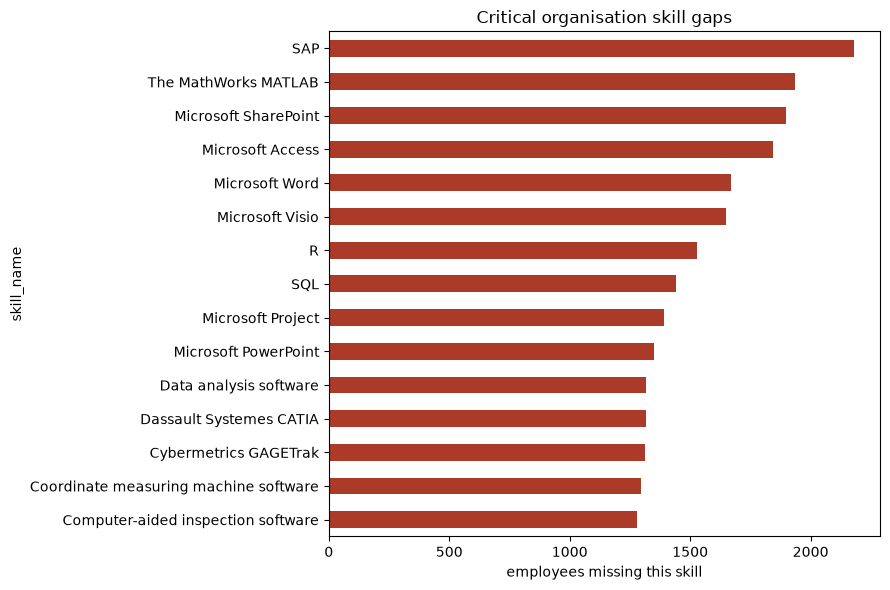

In [3]:
top = org.head(15).iloc[::-1]
colors = top.severity_band.map({"HIGH": "#AC3A28", "MEDIUM": "#8A5D14", "LOW": "#316B51"})
ax = top.plot(kind="barh", x="skill_name", y="employees_missing", figsize=(9, 6),
              color=list(colors), legend=False,
              title="Critical organisation skill gaps")
ax.set_xlabel("employees missing this skill"); plt.tight_layout()